In [1]:
from chython import smarts, smiles
import pandas as pd

In [15]:
# alchemy_rules_path = '../alchemical_out/n1/n1_alchemical_rules.tsv'

alchem_n1_path = '../resu_alchem/n1/n1_alchemical_rules.tsv'
alchem_n5_path = '../resu_alchem/n5/n5_alchemical_rules.tsv'
alchem_all_path = '../resu_alchem/all/all_alchemical_rules.tsv'
alchem_n1_df = pd.read_csv(alchem_n1_path, sep='\t')
alchem_n5_df = pd.read_csv(alchem_n5_path, sep='\t')
alchem_all_df = pd.read_csv(alchem_all_path, sep='\t')

Unique n1 rules: 9203
Unique n5 rules: 50801
Overlap: 8199
Only n1: 1004
Only n5: 42602


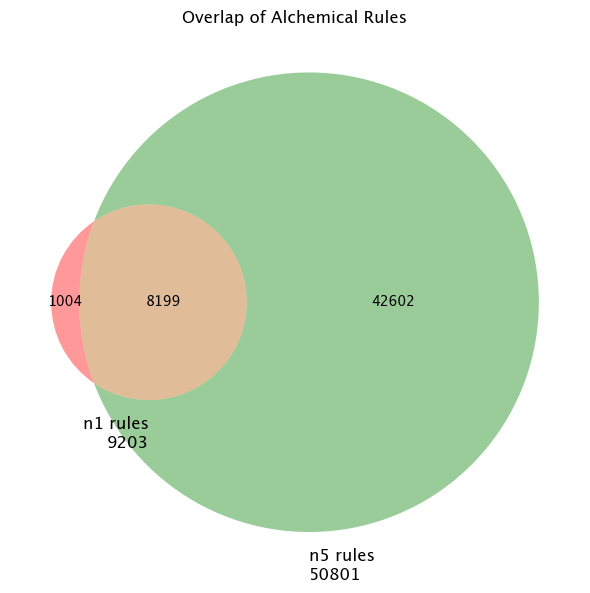

,Alchemical_rule
0,[Br;D1:1]-[C;D2:2]-[C;D2:3]=[C;D2:4]-[C;D3:5]>...
1,[Br;D1:1]-[C;D2:2]-[C;D2:3]>>[Br;D0:1].[C;D3:2...
2,[Br;D1:1]-[C;D2:2]-[C;D2:3]>>[Br;D1:1]-[P;D3:4...
3,[Br;D1:1]-[C;D2:2]-[C;D3:3](:[C;D2:4]):[C;D2:5...
4,[Br;D1:1]-[C;D2:2]-[C;D3:3]>>[Br;D0:1].[C;D3:2...
...,...
8194,[S;D4:1]-[N;D2:2]=[C;D2:3]=[O;D1:4]>>[C;D2:3](...
8195,[S;D4:1]-[N;D2:2]=[C;D2:3]=[O;D1:4]>>[O;D1:4]=...
8196,[S;D4:1]-[N;D3:2](-[C;D2:3]-[C;D3:4])-[C;D2:5]...
8197,[Si;D4:1]-[C;D3:2]:1:[C;D2:3]:[N;D3:4](-[C;D3:...


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

def collect_rule_overlaps(rules_smarts):
    rule_cgrs = []
    for rule_smarts in rules_smarts:
        rule = smarts(rule_smarts)
        rule_cgrs.append(rule)
    return rule_cgrs


n1_rule_cgrs = collect_rule_overlaps(alchem_n1_df["Alchemical_rule"])
n5_rule_cgrs = collect_rule_overlaps(alchem_n5_df["Alchemical_rule"])
all_rule_cgrs = collect_rule_overlaps(alchem_all_df["Alchemical_rule"])

Unique n1 QueryCGRs: 9035
Unique n5 QueryCGRs: 11316
Overlap: 4489
Only n1: 4546
Only n5: 6827


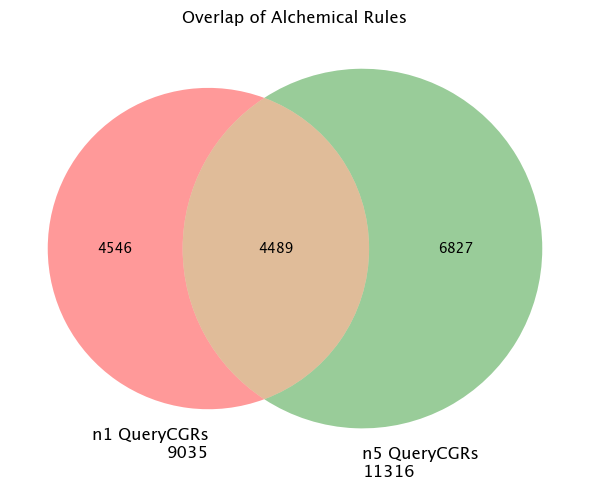

In [18]:
n1_set = set(n1_rule_cgrs)
n5_set = set(n5_rule_cgrs)
# all_set = set(all_rule_cgrs)

overlap_cgrs = n1_set & n5_set
only_n1_cgrs = n1_set - n5_set
only_n5_cgrs = n5_set - n1_set

print("Unique n1 QueryCGRs:", len(n1_set))
print("Unique n5 QueryCGRs:", len(n5_set))
print("Overlap:", len(overlap_cgrs))
print("Only n1:", len(only_n1_cgrs))
print("Only n5:", len(only_n5_cgrs))

plt.figure(figsize=(6, 6))

venn2(
    subsets=(
        len(only_n1_cgrs),
        len(only_n5_cgrs),
        len(overlap_cgrs),
    ),
    set_labels=(
        f"n1 QueryCGRs\n{len(n1_set)}",
        f"n5 QueryCGRs\n{len(n5_set)}",
    ),
)

plt.title("Overlap of Alchemical Rules")
plt.tight_layout()
plt.show()

Unique n1 QueryCGRs: 9035
Unique n5 QueryCGRs: 11316
Unique all QueryCGRs: 48643
n1 ∩ n5: 4489
n1 ∩ all: 8843
n5 ∩ all: 11064
n1 ∩ n5 ∩ all: 4407


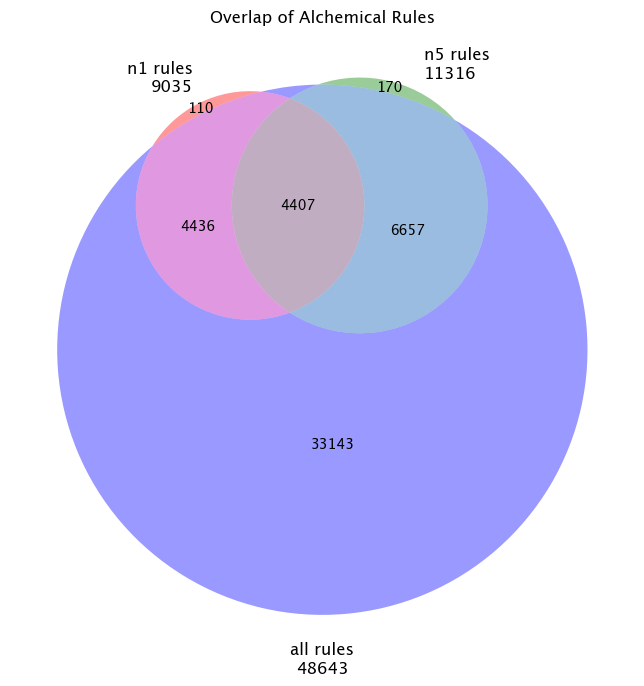

In [20]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Convert QueryCGRContainer lists to sets
n1_set = set(n1_rule_cgrs)
n5_set = set(n5_rule_cgrs)
all_set = set(all_rule_cgrs)

# Basic counts
print("Unique n1 QueryCGRs:", len(n1_set))
print("Unique n5 QueryCGRs:", len(n5_set))
print("Unique all QueryCGRs:", len(all_set))

print("n1 ∩ n5:", len(n1_set & n5_set))
print("n1 ∩ all:", len(n1_set & all_set))
print("n5 ∩ all:", len(n5_set & all_set))
print("n1 ∩ n5 ∩ all:", len(n1_set & n5_set & all_set))

# Venn diagram
plt.figure(figsize=(7, 7))

venn3(
    subsets=(n1_set, n5_set, all_set),
    set_labels=(
        f"n1 rules\n{len(n1_set)}",
        f"n5 rules\n{len(n5_set)}",
        f"all rules\n{len(all_set)}",
    ),
)

plt.title("Overlap of Alchemical Rules")
plt.tight_layout()
plt.show()